<a href="https://colab.research.google.com/github/TheOohWee/CSE-10124-LAB-2/blob/main/Amir_CSE10124_Lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSE 10124 - Building ChatGPT: Lab 02 (5 pts.)

- NETID:

This assignment covers the following topics:
- Word Embeddings, Conceptually
- Linear Transformations
- The Embedding Layer
- Activation Functions
- Linear Layers

It will consist of 8 tasks:

| Task ID  | Description                                      | Points |
|----------|--------------------------------------------------|--------|
| 00       | Data + Libary Loading                          | 0      |
| 01       | Word Embeddings, Conceptually                          | 0.5      |
| &nbsp;&nbsp;&nbsp;&nbsp;01-1     | &nbsp;&nbsp;&nbsp;&nbsp;- Loading and Printing Embeddings                   |      |
| &nbsp;&nbsp;&nbsp;&nbsp;01-2     | &nbsp;&nbsp;&nbsp;&nbsp;- Comparing High Dimensional Vectors                   |      |
| &nbsp;&nbsp;&nbsp;&nbsp;01-3     | &nbsp;&nbsp;&nbsp;&nbsp;- Exploring High Dimensional Relationships                   |    |
| 02       | Linear Transformations                | 1       |
| &nbsp;&nbsp;&nbsp;&nbsp;02-1     | &nbsp;&nbsp;&nbsp;&nbsp;- Linear Transformation Class                   |      |
| &nbsp;&nbsp;&nbsp;&nbsp;02-2     | &nbsp;&nbsp;&nbsp;&nbsp;- Comparison to pytorch nn.Linear                   |      |
| 03       | The Embedding Layer               | 1       |
| &nbsp;&nbsp;&nbsp;&nbsp;03-1     | &nbsp;&nbsp;&nbsp;&nbsp;- EmbeddingLayer Class                   |     |
| &nbsp;&nbsp;&nbsp;&nbsp;03-2     | &nbsp;&nbsp;&nbsp;&nbsp;- Short Answer Questions                   |    |
| &nbsp;&nbsp;&nbsp;&nbsp;03-3     | &nbsp;&nbsp;&nbsp;&nbsp;- Comparison to pytorch nn.Embedding                   |    |
| 04       | Activation Functions              | 1       |
| &nbsp;&nbsp;&nbsp;&nbsp;04-1     | &nbsp;&nbsp;&nbsp;&nbsp;- ReLU Class                   |    |
| &nbsp;&nbsp;&nbsp;&nbsp;04-2     | &nbsp;&nbsp;&nbsp;&nbsp;- Comparison to pytorch F.relu                   |    |
| 05       | Linear Layers              | 0.5       |
| &nbsp;&nbsp;&nbsp;&nbsp;05-1     | &nbsp;&nbsp;&nbsp;&nbsp;- LinearLayer Class                   |    |
| 06       | Neural Network              | 1      |
| &nbsp;&nbsp;&nbsp;&nbsp;06-0     | &nbsp;&nbsp;&nbsp;&nbsp;- Set Colab ENV to GPU/TPU                   |    |
| &nbsp;&nbsp;&nbsp;&nbsp;06-1     | &nbsp;&nbsp;&nbsp;&nbsp;- Custom Neural Network Class                   |    |
| &nbsp;&nbsp;&nbsp;&nbsp;06-2     | &nbsp;&nbsp;&nbsp;&nbsp;- pytorch Neural Network Class                   |    |
| &nbsp;&nbsp;&nbsp;&nbsp;06-3-A/B     | &nbsp;&nbsp;&nbsp;&nbsp;- Neural Network Comparison                   |     |
| 07       | Generate Submission               | 0       |

Please complete all sections. Some questions will require written answers, while others will involve coding. Be sure to run your code cells to verify your solutions.

In the code blocks, look for comments like:
```python
# TODO: some task description
```
as these are what you will be expected to fill in. For code sections longer than a line, there's an additional comment:
```python
# LINES: N
```
where `N` is the number of lines I have in my solution. This is NOT graded on, it is just a reference for you, if you have way more or way fewer it may be worth rethinking your code but +/- 2-3 lines is nothing to worry about usually.

## Task 00: Setup (0 pts.)
#### Loading Data and Importing Libraries

Run the cell below to download the data and libraries and then import our utilities library

### Task 00: Code (0 pts.)

In [ ]:
# @title Load Data and Libraries

import os

try:
    import google.colab
    REPO_URL = "https://github.com/wtheisen/nd-cse-10124-lectures.git"

    REPO_NAME = "/content/nd-cse-10124-lectures"
    L_PATH = "nd-cse-10124-lectures"

    %cd /content/
    !rm -r {REPO_NAME}

    # Clone repo
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}

        # cd into the data folder
        %cd {L_PATH}
        !pwd

except ImportError:
    print("Unable to download repo, either:")
    print("\tA.) You're not on colab")
    print("\tB.) It has already been cloned")

import irishGPT.utilities as uts

/content
rm: cannot remove '/content/nd-cse-10124-lectures': No such file or directory
Cloning into 'nd-cse-10124-lectures'...
remote: Enumerating objects: 466, done.
remote: Counting objects: 100% (55/55), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 466 (delta 19), reused 41 (delta 11), pack-reused 411 (from 1)
Receiving objects: 100% (466/466), 60.58 MiB | 13.52 MiB/s, done.
Resolving deltas: 100% (282/282), done.
/content/nd-cse-10124-lectures
/content/nd-cse-10124-lectures


## Task 01: Word Embeddings
### Task 01-1: Description (0 pts.)
#### Loading and Printing Embeddings

Uncomment `model = get_GloVe` and then run the cell below to import the embeddings for the [`GloVe (Global Vectors for Word Representation)` model](https://nlp.stanford.edu/projects/glove/) from 2014. Under the hood, this model is just a big dictionary that maps from a word to its embedding. Remember that embeddings are high dimensional representations of our word, based on other words they frequently appear around in the training data (and where and how they frequently appear). After loading, the cell will print the first 5 values in the embedding for the word `'meow'`.

For every word that was in the training data, `GloVe` maps `{'WORD': <300 dimensional Embedding>}`

**Note:** The data will take a little time to load (~3 minutes for me).

**Note:** We're only using `GloVe` for `Task 01` so I'd recommend re-commenting out the `get_GloVe` call when you're done so you don't have to wait for it to run every time you are working on the later tasks!

### Task 01-1: Code (0 pts.)

In [ ]:
def get_GloVe():
    !pip install -q gensim

    import gensim.downloader as api
    import numpy as np
    import matplotlib.pyplot as plt

    print("Loading GloVe vectors (300d)...")
    model = api.load("glove-wiki-gigaword-300")
    print("Done.")

    return model

model = None
model = get_GloVe()

if model:
    print("GloVe Embedding for 'meow':")
    print(model['meow'][0:5])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.3 MB/s eta 0:00:00
Loading GloVe vectors (300d)...
[==================================================] 100.0% 376.1/376.1MB downloaded
Done.
GloVe Embedding for 'meow':
[ 0.041175 -0.13816  -0.11133  -0.055945  0.10929 ]


### Task 01-1: Expected Output (0 pts.)
```
Loading GloVe vectors (300d)...
Done.
GloVe Embedding for 'meow':
[ 0.041175 -0.13816  -0.11133  -0.055945  0.10929 ]
```

### Task 01-2: Description (0 pts.)
#### Comparing High-Dimensional Vectors

Once we have high dimensional vectors for words, one thing we can do is compare how similar they are to each other! The most common way for this to be done is using something called `Cosine Similarity`

![Cosine Similarity Equation](https://towardsdatascience.com/wp-content/uploads/2020/09/1LfW66-WsYkFqWc4XYJbEJg.png)

Which sort of just measures the angle between the two vectors (embeddings) in their 300d space. The smaller the angle between the two vectors, the more similar they are!

![Visualization of Angle-Similarity Relationship](https://storage.googleapis.com/lds-media/images/cosine-similarity-vectors.original.jpg)

We can also calculate the `hyperplane` that two points share (such as "woman" and "man") and then project points onto that hyperplan to see where they lie on the "woman-man" dichotomy.

![Projecting a Point onto a Plane](https://i.sstatic.net/bY5oU.png)

Run the code cell below to calculate the `woman-man hyperplane` and project a word onto it.

**Note:** There are many different 'sub-hyperplanes' in this `300d` space, not just a man-woman one! You may find it fun to see if you can find any other interesting ones, if you do let me know! The ones below are examples shown on the original GloVe website.

![GloVe sub-hyperplanes from the GloVe website](https://10124.williamtheisen.com/static/img/lab02/glove_sub_hyperplanes.png)

### Task 01-2: Code (0.5 pts.)

In [ ]:
import numpy as np

def cosine(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def project(word, axis):
    v = model[word]
    return np.dot(v, gender_axis)

gender_axis = model['woman'] - model['man']
gender_axis = gender_axis / np.linalg.norm(gender_axis)

print("Man-Woman Projected Value for 'Programmer':", project('programmer', gender_axis))

Man-Woman Projected Value for 'Programmer': -0.21765128


### Task 01-1: Expected Output (0 pts.)
```
Man-Woman Projected Value for 'Programmer': -0.21765128
```

### Task 01-3: Description (0 pts.)
#### Exploring High Dimensional Relationships

In the cell below, test some new words! See if you can beat my most "masculine" and most "feminine" words!

```
Most "Masculine"
    Soldier: -0.604

Most "Feminine"
    'nurse': 1.863
```

**Note:** More negative is more "masculine", more positive is more "feminine"

**Note:** Remember to keep in mind that nobody actually went through and determined whether a word was supposed to be more masculine or feminine, it was done based entirely on the training data, with no human input other than the fact that the training data was collected from what humans had written on the internet!

### Task 01-3: Code (0.5 pts.)

In [ ]:
#TODO: Try some different words!
words = [
    "gun",
    "nurse",
    "genius",
    "gynecologist",
    "knife",
    "ballerina",
    "strong",
    "stupid",
    "lying",
    "lie",
    "friend",
]

proj_vals = [(w, project(w, gender_axis)) for w in words]
proj_vals.sort(key=lambda x: x[1])

print("Projection onto gender axis (negative = masculine, positive = feminine):\n")
for w, v in proj_vals:
    print(f"{w:15s} {v: .3f}")

Projection onto gender axis (negative = masculine, positive = feminine):

genius          -1.037
gun             -0.604
stupid          -0.294
knife           -0.261
strong          -0.177
friend          -0.112
lie              0.172
lying            0.305
nurse            1.863
gynecologist     2.042
ballerina        2.225


### Task 01-1: Expected Output (0 pts.)
No expected output here, just see if you can find anything more "masculine" than `'gun'` and more "feminine" than `'nurse'`!

## Task 02: Linear Transformations
### Task 02-1: Description (0 pts.)
#### Simple Matrix Multiplications

We can create these embeddings by performing a `linear transformation` which is a way to change the dimensionality of our data!

![Linear Transformation from 2D to 3D](https://www.cs.bu.edu/fac/snyder/cs132-book/_images/L08MatrixofLinearTranformation_4_0.jpg)

In Deep Learning this usually takes the form of a matrix multiplication. What we learn when we train a neural network is the best set of `weights` which are what actually "map" between our high dimensional input space and our low dimensional target space! For MNIST we map between `<784>` dimensional input space and our `<10>` dimensional "answer" space.

In the cell below, fill in the code to create a class to perform a linear transformation!

### Task 02-1: Code (0.5 pts.)

In [ ]:
import math
import torch

class LinearTransformation():
    def __init__(self, in_dim, out_dim):
        k = 1.0 / math.sqrt(in_dim)

        self.W = torch.empty(out_dim, in_dim).uniform_(-k, k)
        self.b = torch.empty(out_dim).uniform_(-k, k)

    def forward(self, x_batch):
        self.x_batch = x_batch

        #TODO: Perform a linear transformation with x_batch from in_dim to out_dim, remember to add the bias!
        return x_batch @ self.W.T + self.b

In [ ]:
zoo = {'Monkeys': [], 'Cats': []}

class Animal():
    def __init__(self, name, color, sound):
        self.name = name
        self.color = color
        self.sound = sound

    def introduce(self):
        print(f'Hello my name is {self.name}')

    def make_noise(self):
        print(self.sound)

class Monkey(Animal):
    def __init__(self, name, color, sound, bananas=3):
        super().__init__(name, color, sound)
        self.bananas = bananas

    def peel_ban(self):
        print(f'Peeling {self.bananas} bananas')
        self.bananas = 0

monkey_1 = Monkey('liam', 'brown', 'Weeeeeee')
monkey_1.introduce()
monkey_1.make_noise()
monkey_1.peel_ban()
monkey_1.peel_ban()

monkey_2 = Monkey('punch', 'grey', 'cryyyy', 5)
monkey_2.introduce()
monkey_2.make_noise()
monkey_2.peel_ban()

zoo['Monkeys'].append(monkey_1)
zoo['Monkeys'].append(monkey_2)

print(zoo)

class Cat(Animal):
    def purr(self):
        print(f'Purrrrrrrrrrrr')

cat_1 = Cat('bill', 'blue', 'yipeeee')
cat_1.make_noise()
cat_1.purr()

zoo['Cats'].append(cat_1)

print(zoo)

Hello my name is liam
Weeeeeee
Peeling 3 bananas
Peeling 0 bananas
Hello my name is punch
cryyyy
Peeling 5 bananas
{'Monkeys': [<__main__.Monkey object at 0x7953cf1d9fd0>, <__main__.Monkey object at 0x7953cf1d8e90>], 'Cats': []}
yipeeee
Purrrrrrrrrrrr
{'Monkeys': [<__main__.Monkey object at 0x7953cf1d9fd0>, <__main__.Monkey object at 0x7953cf1d8e90>], 'Cats': [<__main__.Cat object at 0x7953cf1daf60>]}


### Task 02-2: Description (0 pts.)
#### Testing the Class

pytorch has a built in class for this called `nn.Linear()`, lets compare our class to this one!

In the cell below, create an instance of our `LinearTransformation` class and pass into it the vector for `'meow'` from GloVe. Lets transform it down to `<10>` dimensions and see if our class gives the same thing as pytorch's!

### Task 02-2: Code (0 pts.)

In [ ]:
import torch

torch.manual_seed(42)

# TODO: Create an instance of our LinearTransformation class called l_t
l_t = LinearTransformation(300, 10)

pyt_l_t = torch.nn.Linear(300, 10)

# This code copies the weights that pytorch uses to our linear transformation to make sure they're the same!
with torch.no_grad():
    l_t.W.copy_(pyt_l_t.weight)
    l_t.b.copy_(pyt_l_t.bias)

tensor_vector = torch.tensor(model['meow'])

# TODO: Use l_t to transform the <300> tensor_vector down to <10> and print
print(l_t.forward(tensor_vector))

print(pyt_l_t.forward(tensor_vector))

tensor([-0.0018, -0.3308,  0.1971, -0.0337,  0.1491, -0.0726,  0.0573, -0.1312,
        -0.2818,  0.0418])
tensor([-0.0018, -0.3308,  0.1971, -0.0337,  0.1491, -0.0726,  0.0573, -0.1312,
        -0.2818,  0.0418], grad_fn=<ViewBackward0>)


### Task 02-2: Expected Output (0.5 pts.)
```
tensor([-0.0018, -0.3308,  0.1971, -0.0337,  0.1491, -0.0726,  0.0573, -0.1312,
        -0.2818,  0.0418])
tensor([-0.0018, -0.3308,  0.1971, -0.0337,  0.1491, -0.0726,  0.0573, -0.1312,
        -0.2818,  0.0418], grad_fn=<ViewBackward0>)
```

Cool! Our little class does exactly the same thing as pytorch's!

## Task 03: The Embedding Layer
### Task 03-1: Description (0 pts.)
#### Embedding Layer Class

The cell below contains the code for the `EmbeddingLayer` we will use when we finally create our own GPT. Read the cell below and then answer the questions that follow.

### Task 03-1: Code (0 pts.)

In [ ]:
# alright now i understand that embedding layer is just a lookup table that we need to fetch token ids with their numerical representations


import torch
import math

class EmbeddingLayer():
    """
    An embedding layer

    Attributes:
        vocab_size (int): Size of the vocabulary in tokens
        embed_dim (int): Size of the token embedding
        tokens (torch.Tensor): Cached input used during the forward pass.
        W (torch.Tensor): Weight matrix with shape (output_dim, input_dim).
        dW (torch.Tensor): Gradient with respect to the weights.
    """
    def __init__(self, vocab_size, embed_dim, device="cpu"):
        """
        Initialize the EmbeddingLayer

        Args:
            vocab_size (int): Number of tokens in the vocab
            embed_dim (int): Size of the token embedding

        Returns:
            None

        Notes:
            Weights are initialized from a normal distribution and scaled by sqrt(2/vocab_size) (He initialization).
        """

        self.device = device
        self.vocab_size = vocab_size

        k = 1.0 / math.sqrt(vocab_size)

        self.W = torch.empty(vocab_size, embed_dim).normal_(mean=0.0, std=1.0)

    def forward(self, tokens):
        """
        Compute the forward pass of the embedding layer.

        Args:
            tokens (torch.Tensor): Input data with shape (batch_size, sequence_length)

        Returns:
            torch.Tensor: Embedding output with shape (batch_size, sequence_length, embed_dim)
        """

        self.tokens = tokens

        embeddings = self.W[tokens] # (batch_size, sequence_length, embedding_dim)

        # Return contiguous tensor for memory contiguity
        return embeddings.contiguous()


        def backward(self, dY):

          """
        Compute the backward pass of the embedding layer.

        Args:
            dY (torch.Tensor): Gradient with respect to the output of the embedding layer

        Returns:
            None (Predicated on being the first layer in the model)
        """

        tokens = self.tokens
        embedding_dim, vocab_size = self.W.shape

        self.dW = torch.zeros(embedding_dim, vocab_size, device=dY.device, dtype=dY.dtype)

        batch_size, sequence_length = tokens.shape
        tokens_flat = tokens.reshape(batch_size * sequence_length)
        dY_flat = dY.reshape(batch_size * sequence_length, embedding_dim).T

        # accumulate columns: dW[:, tokens_flat[k]] += dY_flat[:, k]
        self.dW.index_add_(dim=1, index=tokens_flat, source=dY_flat)


    # original backward method in the assignment had embedding_dim, vocab_size.
    # I changed that, but I am not sure if I am right.
    # alright it was not matching next expected outputs so I change it back
        """
      def backward(self, dY):
        tokens = self.tokens
        vocab_size, embedding_dim = self.W.shape  # ✓ fixed order

        self.dW = torch.zeros(vocab_size, embedding_dim, device=dY.device, dtype=dY.dtype)  # ✓ fixed shape

        batch_size, sequence_length = tokens.shape
        tokens_flat = tokens.reshape(batch_size * sequence_length)
        dY_flat = dY.reshape(batch_size * sequence_length, embedding_dim).T

        self.dW.index_add_(dim=1, index=tokens_flat, source=dY_flat)
      """

    def update(self, lr):
        """
        Update the parameters of the layer using gradient descent.

        Args:
            lr (float): Learning rate for the parameter update.

        Returns:
            None
        """

        # Update the weights of the layer using the learning rate
        self.W -= lr * self.dW

### Task 03-2: Short Answer Questions (0.5 pts.)

* List two differences you can find between this `EmbeddingLayer` and our `LinearTransformation` class above (something like "number of lines" doesn't count).
    1. Linear Transformation does x @ W.T + b while EmbeddingLayer does a row lookup from the already known embeddings fetching by index
    2. lt takes continuous vectors like embeddings as input while el takes token ids which as integers as input, so it is the layer that creates the vectors in the first place and then only lt

### Task 03-2: Description (0 pts.)
#### Testing the Embedding Layer

Lets compare our embedding layer to the built-in one in pytorch! Run the code cell below to compare the two!

### Task 03-2: Code (0 pts.)

In [ ]:
import torch
import irishGPT.tokenizer as tokenizer
torch.manual_seed(42)
pyt_e = torch.nn.Embedding(512, 128)

our_e = EmbeddingLayer(512, 128)

# This code copies the weights that pytorch uses to our linear transformation to make sure they're the same!
with torch.no_grad():
    our_e.W.copy_(pyt_e.weight)

tok = tokenizer.Regex_Tokenizer()
training_str = uts.get_file_as_string('Datasets/zoomer.txt')
tok.train(training_str, 512)

prompt = '<|sos|>No cap are u rolling club hes tn?<|eos|>'
print('Input Prompt:', prompt)

tokens = tok.encode(prompt)
print('Tokenized Prompt:', tokens)

print('#' * 80)

tokens = torch.tensor(tokens, dtype=torch.long).unsqueeze(0)

our_token_embeddings = our_e.forward(tokens)
print(our_token_embeddings.shape)
print('Our first 10 embedding values for the second token (no)')
print(our_token_embeddings[0][1][:10])

print('#' * 80)

pyt_token_embeddings = pyt_e(tokens)
print(pyt_token_embeddings.shape)
print('pytorch first 10 embedding values for the second token (no)')
print(pyt_token_embeddings[0][1][:10])

Input Prompt: <|sos|>No cap are u rolling club hes tn?<|eos|>
Tokenized Prompt: [257, 78, 111, 283, 97, 112, 264, 272, 360, 32, 341, 286, 270, 283, 108, 117, 98, 329, 115, 259, 110, 63, 258]
################################################################################
torch.Size([1, 23, 128])
Our first 10 embedding values for the second token (no)
tensor([-1.0284, -0.6862,  0.1060, -0.1432,  0.5898,  0.1672,  1.3842, -1.2705,
        -0.4187, -1.6622])
################################################################################
torch.Size([1, 23, 128])
pytorch first 10 embedding values for the second token (no)
tensor([-1.0284, -0.6862,  0.1060, -0.1432,  0.5898,  0.1672,  1.3842, -1.2705,
        -0.4187, -1.6622], grad_fn=<SliceBackward0>)


**P.S. MY OUTPUT IS DIFFERENT BECAUSE I CHANGED VOCAB_SIZE AND EMBED_DIM PLACES**

### Task 03-3: Expected Output (0.5 pts.)
```
Input Prompt: <|sos|>No cap are u rolling club hes tn?<|eos|>
Tokenized Prompt: [256, 78, 111, 282, 97, 112, 263, 271, 359, 32, 340, 285, 269, 282, 108, 117, 98, 328, 115, 258, 110, 63, 257]
################################################################################
torch.Size([1, 23, 128])
Our first 10 embedding values for the second token (no)
tensor([ 0.2343, -0.5058,  0.7136, -1.1381, -0.9068,  0.0497, -1.0774,  0.3302,
         1.1632,  0.3392])
################################################################################
torch.Size([1, 23, 128])
pytorch first 10 embedding values for the second token (no)
tensor([ 0.2343, -0.5058,  0.7136, -1.1381, -0.9068,  0.0497, -1.0774,  0.3302,
         1.1632,  0.3392], grad_fn=<SliceBackward0>)
```

## Task 04: Activation Functions
### Task 04: Description (0 pts.)
#### ReLU Activation Function Class

Embeddings don't really require an activation (nor do they have a bias term) but as we saw in [`Lecture 10`](https://colab.research.google.com/drive/1jqnQsAH-13WgFIYD2ngOvnG9G1Gq8SjM?usp=sharing) it's critically important for our Neural Networks (if we want to do anything harder than MNIST) that we add non-linearity to our linear transformations.

We do this via `Activation Functions` and we wrote a simple one in class that is called `ReLU (Rectified Linear Unit)`. We will need a ReLU for our version of GPT so lets write a simple class for it, similar to our `EmbeddingLayer` class.

In the cell below, finish up the code for the ReLU class!

**Note:** You may find it useful to use the [`torch.maximum()` function](https://docs.pytorch.org/docs/stable/generated/torch.maximum.html)

### Task 05: Code (0.5 pts.)

In [ ]:
import torch

class ReLU:
    """
    Element-wise rectified linear activation.
    """
    def forward(self, X):
        """
        Apply ReLU activation and cache the input tensor.

        Args:
            X (torch.Tensor): Input tensor of any shape.

        Returns:
            torch.Tensor: Tensor with negatives zeroed out, same shape as `X`.
        """

        self.X = X
        zero = torch.tensor(0.0, device=X.device)

        # TODO: Calculate and return the output of the ReLU layer
        return torch.maximum(X, zero)

    def backward(self, dA):
        """
        Propagate gradients through the ReLU non-linearity.

        Args:
            dA (torch.Tensor): Upstream gradient matching the shape of the forward output.

        Returns:
            torch.Tensor: Gradient with respect to the input, zeroed where the cached input was non-positive.
        """


        return dA * (self.X > 0)

    def update(self, lr):
        """
        Keep API parity with trainable layers; ReLU has no parameters to update.

        Args:
            lr (float): Unused learning rate argument.

        Returns:
            None
        """
        pass


## Task 04: Activation Functions
### Task 04-2: Description (0 pts.)
#### Comparing our class to pytorch

Lets compare how our ReLU does vs. the built-in one in pytorch!

Run the cell below to compare the two.

### Task 04-2: Code (0 pts.)

In [ ]:
# TODO: Create an instance of our ReLU class
relu = ReLU()

print('Our ReLU Output:')
print(relu.forward(our_token_embeddings[0][0])[:10])
print('pytorch ReLU Output:')
print(torch.nn.functional.relu(our_token_embeddings[0][0])[:10])

Our ReLU Output:
tensor([0.0000, 0.0000, 1.2376, 2.0860, 1.0039, 0.8636, 1.0318, 0.0000, 0.0000,
        0.0000])
pytorch ReLU Output:
tensor([0.0000, 0.0000, 1.2376, 2.0860, 1.0039, 0.8636, 1.0318, 0.0000, 0.0000,
        0.0000])


### Task 04-2: Expected Output (0.5 pts.)
```
torch.Size([1, 23, 128])
Our ReLU Output:
tensor([1.1065, 0.5547, 0.0000, 1.3759, 0.3438, 0.7569, 0.0000, 0.5588, 0.0000,
        1.1770])
pytorch ReLU Output:
tensor([1.1065, 0.5547, 0.0000, 1.3759, 0.3438, 0.7569, 0.0000, 0.5588, 0.0000,
        1.1770])
```

## Task 05: Linear Layers
### Task 05-1: Description (0 pts.)
#### Linear Layer Class

Our `LinearTransformation` code from above was missing a few critical functions if we want to use it as a full `LinearLayer` in a neural network, namely:
1. backwards (this is where we calculate the gradients for the layer)
2. update (this is where we use the gradients to update our weights and learn!)

In the cell below, copy in the code from [`Lecture10`](https://colab.research.google.com/drive/1jqnQsAH-13WgFIYD2ngOvnG9G1Gq8SjM?usp=sharing) for the `backwards` and `update` functions to allow us to use our `LinearTransformation` class as a full `LinearLayer`!

### Task 05-1: Code (0.5 pts.)

In [ ]:
import math
import torch

class LinearLayer:
    """
    A fully connected (dense) layer that performs a linear transformation.

    Attributes:
        W (torch.Tensor): Weight matrix with shape (output_dim, input_dim).
        b (torch.Tensor): Bias vector with shape (output_dim, 1).
        X (torch.Tensor): Cached input used during the forward pass.
        dW (torch.Tensor): Gradient with respect to the weights.
        db (torch.Tensor): Gradient with respect to the biases.
    """
    def __init__(self, input_dim, output_dim, device='cpu'):
        """
        Initialize the LinearLayer with random weights and biases using He initialization.

        Args:
            input_dim (int): Dimension of the input features.
            output_dim (int): Number of neurons (output features).

        Returns:
            None

        Notes:
            Weights and biases are initialized from a normal distribution and scaled by sqrt(2/input_dim) (He initialization).
        """
        self.device = device

        self.W = torch.randn(output_dim, input_dim, device=self.device) * math.sqrt(2.0 / input_dim)
        self.b = torch.randn(1, output_dim, device=self.device) * math.sqrt(2.0 / input_dim)

    def forward(self, X):
        """
        Compute the forward pass of the linear layer.

        Args:
            X (torch.Tensor): Input data with shape (input_dim, m) where m is the number of examples.

        Returns:
            Z (torch.Tensor): Linear output with shape (output_dim, m)

        Notes:
            The input X is stored for use during backpropagation.
        """

        self.X = X

        return X @ self.W.T + self.b

    def backward(self, dA):
        """
        Compute the backward pass of the linear layer.

        Args:
            dY (torch.Tensor): Gradient with respect to the output of the linear layer (batch_size, output_dim)

        Returns:
            dX (torch.Tensor): Gradient with respect to the input of the linear layer (batch_size, input_dim)
        """

        # TODO: Calculate the gradient of the loss with respect to the weights and biases
        self.dW = dA.T @ self.X / self.X.shape[0]
        self.db = dA.mean(dim=0, keepdim=True)

        # Return the gradient of the loss with respect to the input
        return dA @ self.W

    def update(self, lr):
        """
        Update the parameters of the layer using gradient descent.

        Args:
            lr (float): Learning rate for the parameter update.

        Returns:
            None
        """

        # TODO: Update the weights and biases of the layer using the learning rate
        self.W -= lr * self.dW
        self.b -= lr * self.db


## Task 06: Simple Neural Network
### Task 06-0: Description (0 pts.)
#### Properly set colab env

**[WARNING]:** Colab only gives limited GPU runtime to users, and it takes quite some time to refresh. I would recommend you first test and debug your code on the CPU environment to first make sure you can actually produce results, and only switch to the GPU environment when you're planning on doing your final run-through.

Training our Neural Networks is very slow and the easiest way to speed this up is training our networks on the GPU! Colab gives free (limited) access to GPUs. You can follow the steps below to change your environment to be one with a GPU.

1. Select the `Change runtime type` from the environment dropdown in the upper right

<img src="https://raw.githubusercontent.com/nd-cse-30124-fa25/nd-cse-30124-fa25.github.io/refs/heads/main/static/img/hw03/change_runtime_2.png" alt="Map" style="width: 100%; max-width: 800px; height: auto;">

2. Select t4 GPU as your environment

<img src="https://raw.githubusercontent.com/nd-cse-30124-fa25/nd-cse-30124-fa25.github.io/refs/heads/main/static/img/hw03/change_runtime_1.png" alt="Map" style="width: 100%; max-width: 800px; height: auto;">

**Note:** My estimated runtimes are all on the GPU, if yours is *wayyyy* slower you may check to make sure that you're utilizing one.

### Task 06-1: Description (0 pts.)
#### Simple Neural Network Class

The cell below wraps up our LinearLayer and ReLU into a full neural network architecture that we can train! See if you can find how many layers we have in the model.

Run the cell below to instantiate the class so we can create a neural network to train on CIFAR10!

**Note:** There are a number of minimized code cells beneath this one that you will need to run too to make sure we have everything we need.

### Task 06-1: Code (0 pts.)

In [ ]:
class NeuralNetwork:
    """
    Feed-forward network assembled from the custom Linear, ReLU, and Softmax layers.

    The model consumes flattened images `(batch_size, 3072)` and produces
    probability distributions over 10 CIFAR10 classes.

    Attributes:
        device (torch.device): Device used for parameters and computation.
        layers (list): Ordered sequence of layers applied during forward().
    """
    def __init__(self, device='cpu', seed=42):
        """
        Build the fully connected architecture and seed the random generator.

        Args:
            device (torch.device or str): Device used for tensors and parameters.
            seed (int): Random seed for deterministic weight initialization.
        """
        self.device = device

        self.layers = [
            LinearLayer(3072, 1024, device=self.device),
            ReLU(),
            LinearLayer(1024, 512, device=self.device),
            ReLU(),
            LinearLayer(512, 256, device=self.device),
            ReLU(),
            LinearLayer(256, 10, device=self.device)
            ]

    def forward(self, X, eval=False):
        """
        Sequentially apply each layer in the network.

        Args:
            X (torch.Tensor): Batch of flattened images of shape (batch_size, 3072).
            eval (bool): If True, apply softmax to the final output.

        Returns:
            torch.Tensor: Probabilities of shape (batch_size, 10).
        """
        for layer in self.layers:
            X = layer.forward(X)

        return X if not eval else self.softmax(X)

    def softmax(self, X):
        """
        Args:
            X (torch.Tensor): Input data with shape (n_classes, m), where n_classes is the number of classes
                               and m is the number of examples.

        Returns:
            numpy.ndarray: Softmax probabilities with shape (n_classes, m).
        """

        return F.softmax(X, dim=-1)

    def cross_entropy(self, logits, Y):
        """
        Compute the mean cross-entropy loss for one-hot encoded targets.

        Args:
            logits (torch.Tensor): Raw output logits of shape (batch_size, num_classes).
            Y (torch.Tensor): One-hot encoded targets with the same shape.

        Returns:
            torch.Tensor: Scalar loss tensor averaged over the batch.
        """

        log_probs = logits - logits.logsumexp(dim=1, keepdim=True)
        return -(Y * log_probs).sum(dim=1).mean()

    def get_accuracy(self, logits, Y):
        """
        Calculate classification accuracy for one-hot encoded labels.

        Args:
            logits (torch.Tensor): Raw output logits of shape (batch_size, num_classes).
            Y (torch.Tensor): One-hot encoded targets with the same shape.

        Returns:
            torch.Tensor: Scalar tensor containing the accuracy fraction.
        """

        return (logits.argmax(dim=1) == Y.argmax(dim=1)).float().mean()

    def backprop(self, logits, Y):
        """
        Backpropagate the cross-entropy gradient through all layers.

        Args:
            logits (torch.Tensor): Raw output logits of shape (batch_size, num_classes).
            Y (torch.Tensor): One-hot encoded targets with the same shape.

        Side Effects:
            Updates each layer's cached gradients in preparation for parameter updates.
        """

        log_probs = logits - logits.logsumexp(dim=1, keepdim=True)
        Y_hat = log_probs.exp()

        dA = Y_hat - Y

        for layer in reversed(self.layers):
            dA = layer.backward(dA)

    def train(self, train_loader, test_loader, epochs=51, learning_rate=0.001, verbose=True):
        """
        Train the network using mini-batch gradient descent on the provided loaders.

        Args:
            train_loader (DataLoader): Iterable that yields training batches.
            val_loader (DataLoader): Iterable that yields validation batches.
            epochs (int): Number of epochs to iterate over the training data.
            learning_rate (float): Step size used during gradient descent updates.
            verbose (bool): If True, log metrics every 10 epochs.

        Returns:
            dict: Contains `loss_history` and `accuracy_history` measured on the validation data.
        """

        train_losses, train_accs = [], []
        test_losses, test_accs = [], []

        for epoch in range(epochs):
            batch_losses, batch_accs = [], []

            for X_batch, Y_batch in train_loader:
                X_batch = torch.flatten(X_batch.squeeze(1).to(device), start_dim=1)
                Y_batch = torch.nn.functional.one_hot(Y_batch, num_classes=10).float().to(device)

                # Forward propagation
                Y_hat = self.forward(X_batch)

                batch_losses.append(self.cross_entropy(Y_hat, Y_batch))
                batch_accs.append(self.get_accuracy(Y_hat, Y_batch) * 100)

                # Backward propagation
                self.backprop(Y_hat, Y_batch)

                # Update parameters
                for layer in self.layers:
                    layer.update(learning_rate)

            train_losses.append(torch.mean(torch.tensor(batch_losses).float()))
            train_accs.append(torch.mean(torch.tensor(batch_accs).float()))

            for X_batch, Y_batch in test_loader:
                X_batch = torch.flatten(X_batch.squeeze(1).to(device), start_dim=1)
                Y_batch = torch.nn.functional.one_hot(Y_batch, num_classes=10).float().to(device)

                # Calculate metrics for the whole epoch on the validation set
                Y_hat_full = self.forward(X_batch)
                loss = self.cross_entropy(Y_hat_full, Y_batch)
                acc = self.get_accuracy(Y_hat_full, Y_batch)

                batch_losses.append(loss)
                batch_accs.append(acc * 100)

            test_losses.append(torch.mean(torch.tensor(batch_losses).float()))
            test_accs.append(torch.mean(torch.tensor(batch_accs).float()))

            if epoch % 10 == 0:
                print(f"[epoch {epoch:02d}]:")
                print(f"\t* TRAIN: loss={train_losses[-1]:.4f}, acc={train_accs[-1]:.4f}%")
                print(f"\t* TEST: loss={test_losses[-1]:.4f}, acc={test_accs[-1]:.4f}%")

### Task 06-2: Description (0 pts.)
#### pytorch Neural Network Class

In the cell below, finish the pytorch class's `forward` function to correctly produce the output from our model! You can use the code from [`Lecture10`](https://colab.research.google.com/drive/1jqnQsAH-13WgFIYD2ngOvnG9G1Gq8SjM?usp=sharing) as a reference.

### Task 06-2: Code (0.5 pts.)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class FFN(nn.Module):
    def __init__(self):
        super().__init__()
        # Define model architecture
        self.fc1 = nn.Linear(3072, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 10)

    def forward(self, x):
        # TODO: Finish the forward function to correctly produce the output from our model
        # LINES: 4
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))

        x = F.relu(self.fc3(x))
        x = self.fc4(x)

        return x


device: cuda
train subset size: 50000


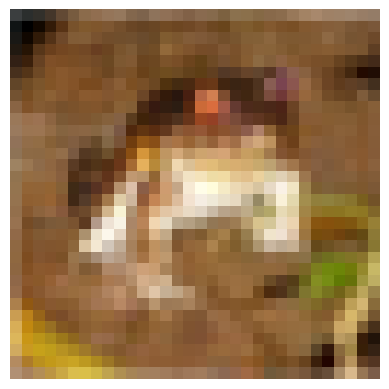

tensor([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]], device='cuda:0')


In [ ]:
# @title CIFAR10 Data Loader

import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
])


def load_ds(train_ds, test_ds):
    N_TRAIN = 1024  # size of subset

    random.seed(42)

    batch_size = 32
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)

    example_img = train_ds[0][0].to(device)
    example_expected = torch.nn.functional.one_hot(torch.tensor(train_ds[0][1]), num_classes=10).float().unsqueeze(0).to(device)

    print("train subset size:", len(train_ds))

    plt.figure()
    plt.imshow(example_img.cpu().squeeze().permute(1, 2, 0))
    plt.axis("off")
    plt.show()

    print(example_expected)

    return train_loader, test_loader, example_img, example_expected

train_full = datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_ds = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

train_loader, test_loader, example_img, example_expected = load_ds(train_full, test_ds)

In [ ]:
# @title pytorch FFN Training Loop and Evaluation Function

@torch.no_grad()
def evaluate(loader, model, device='cpu'):
    total_loss, correct, seen = 0.0, 0, 0
    for x, y in loader:
        x_test = torch.flatten(x.squeeze(1).to(device), start_dim=1)
        y_test = torch.nn.functional.one_hot(y, num_classes=10).float().to(device)

        logits = model.forward(x_test)
        loss = F.cross_entropy(logits, y_test)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(dim=1) == y_test.argmax(dim=1)).sum().item()
        seen += x.size(0)

    return total_loss / seen, correct / seen

def train(model, train_loader, val_loader, device, epochs=51, lr=1e-3):
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    for epoch in range(1, epochs + 1):
        total_loss, correct, seen = 0.0, 0, 0
        batch_losses, batch_accs = [], []

        for x_train, y_train in train_loader:
            x_train = torch.flatten(x_train.squeeze(1).to(device), start_dim=1)
            y_train = torch.nn.functional.one_hot(y_train, num_classes=10).float().to(device)

            logits = model.forward(x_train)

            loss = F.cross_entropy(logits, y_train)
            batch_losses.append(loss)

            # Differentiate L with respect to w
            loss.backward()

            #log_probs = logits - logits.logsumexp(dim=1, keepdim=True)
            #Y_hat = log_probs.exp()

            #dA = Y_hat - y_train

            # Update our weights
            #model.backward(dA, lr)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            batch_accs.append((logits.argmax(dim=1) == y_train.argmax(dim=1)).float().mean().item() * 100)

        model.eval()
        train_losses.append(torch.mean(torch.Tensor(batch_losses)))
        train_accs.append(torch.mean(torch.Tensor(batch_accs)))
        te_loss, te_acc = evaluate(test_loader, model, device)
        test_losses.append(te_loss)
        test_accs.append(te_acc * 100)
        model.train()

        if epoch % 10 == 0:
            print(f"[epoch {epoch:02d}]:")
            print(f"\t* TRAIN: loss={train_losses[-1]:.4f}, acc={train_accs[-1]:.4f}%")
            print(f"\t* TEST: loss={test_losses[-1]:.4f}, acc={test_accs[-1]:.4f}%")



### Task 06-3: Description (0 pts.)
#### Comparing to pytorch neural network

Now that we have our own neural network, lets see how it does on the CIFAR10 dataset compared to a pytorch neural network! Run the two cells below to train the two networks and compare their loss and accuracy on the dataset!

**Note:** It's pretty slow to train (~10 minutes for me), which is why I've split it into two cells, that way you don't have to run both every time.

### Task 06-3: Code (0 pts.)

In [ ]:
# TODO: Create an instance of our pytorch class
torch_model = FFN().to(device)

print('Training Torch Model:')
train(torch_model, train_loader, test_loader, device=device)

Training Torch Model:


/tmp/ipykernel_1852/2294501898.py:56: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  train_losses.append(torch.mean(torch.Tensor(batch_losses)))


[epoch 10]:
	* TRAIN: loss=1.3611, acc=50.7877%
	* TEST: loss=1.4712, acc=48.4300%
[epoch 20]:
	* TRAIN: loss=1.1775, acc=57.5176%
	* TEST: loss=1.5025, acc=49.7300%
[epoch 30]:
	* TRAIN: loss=1.0398, acc=62.5000%
	* TEST: loss=1.5934, acc=49.7100%
[epoch 40]:
	* TRAIN: loss=0.9450, acc=65.7790%
	* TEST: loss=1.7593, acc=49.8700%
[epoch 50]:
	* TRAIN: loss=0.8593, acc=68.8520%
	* TEST: loss=1.9078, acc=48.9000%


### Task 06-3-A: Reference Output (0.25 pts.):
```
Training Torch Model:
[epoch 10]:
	* TRAIN: loss=1.3647, acc=51.0177%
	* TEST: loss=1.5078, acc=46.8700%
[epoch 20]:
	* TRAIN: loss=1.1878, acc=57.0937%
	* TEST: loss=1.4982, acc=48.9300%
[epoch 30]:
	* TRAIN: loss=1.0543, acc=61.7602%
	* TEST: loss=1.5763, acc=49.4400%
[epoch 40]:
	* TRAIN: loss=0.9409, acc=65.6530%
	* TEST: loss=1.7960, acc=47.9400%
[epoch 50]:
	* TRAIN: loss=0.8601, acc=68.6880%
	* TEST: loss=1.9956, acc=47.8400%
```

**Note:** Depending on how and when you run the code, due to random weight initialization, your values may be slightly different than mine and that's okay.

**Note:** The cell below took me ~8 minutes to run!

In [ ]:
print('Training Our Model:')

# TODO: Initialize our model
model = NeuralNetwork(device=device)

model.train(train_loader, test_loader)

Training Our Model:
[epoch 00]:
	* TRAIN: loss=1.9786, acc=29.9804%
	* TEST: loss=1.9557, acc=30.9135%
[epoch 10]:
	* TRAIN: loss=1.5094, acc=47.3409%
	* TEST: loss=1.5137, acc=47.1682%
[epoch 20]:
	* TRAIN: loss=1.3737, acc=52.2053%
	* TEST: loss=1.3838, acc=51.6525%
[epoch 30]:
	* TRAIN: loss=1.2721, acc=55.6842%
	* TEST: loss=1.2892, acc=54.9723%
[epoch 40]:
	* TRAIN: loss=1.1832, acc=58.8472%
	* TEST: loss=1.2093, acc=57.8108%
[epoch 50]:
	* TRAIN: loss=1.1025, acc=61.8462%
	* TEST: loss=1.1424, acc=60.2595%


### Task 06-3-B: Reference Output (0.25 pts.)
```
Training Our Model:
[epoch 00]:
	* TRAIN: loss=1.8335, acc=33.7072%
	* TEST: loss=1.8010, acc=35.1313%
[epoch 10]:
	* TRAIN: loss=1.1955, acc=57.2677%
	* TEST: loss=1.2268, acc=56.2916%
[epoch 20]:
	* TRAIN: loss=0.8543, acc=69.5877%
	* TEST: loss=0.9642, acc=66.7994%
[epoch 30]:
	* TRAIN: loss=0.5479, acc=80.2263%
	* TEST: loss=0.7445, acc=75.7696%
[epoch 40]:
	* TRAIN: loss=0.3462, acc=87.6020%
	* TEST: loss=0.6613, acc=81.7964%
[epoch 50]:
	* TRAIN: loss=0.2473, acc=91.2328%
	* TEST: loss=0.6605, acc=84.9164%
```

**Note:** Depending on how and when you run the code, due to random weight initialization, your values may be slightly different than mine and that's okay.

## Task 07: Generate Submission
### Task 07: Description (0 pts.)

Uncomment the function call at the end of the code block to generate the file to submit on canvas.

### Task 07: Code (0 pts.)

In [ ]:
import os, json

def export_notebook():
    L_PATH = "nd-cse-10124-lectures/Notebooks"
    L = "Lab_02_Embedding"

    try:
        from google.colab import _message, files

        repo_ipynb_path = f"/content/{L_PATH}/{L}.ipynb"
        nb = _message.blocking_request("get_ipynb", timeout_sec=1)["ipynb"]

        os.makedirs(os.path.dirname(repo_ipynb_path), exist_ok=True)
        with open(repo_ipynb_path, "w", encoding="utf-8") as f:
            json.dump(nb, f)

        !jupyter nbconvert --to html "{repo_ipynb_path}"
        files.download(repo_ipynb_path.replace(".ipynb", ".html"))
    except:
        import subprocess
        nb_fp = os.getcwd() + f'/{L}.ipynb'
        subprocess.run(["jupyter", "nbconvert", "--to", "html", nb_fp], check=True)

# TODO: Uncomment the line below and run to generate the file to submit on canvas
export_notebook()

[NbConvertApp] Converting notebook /content/nd-cse-10124-lectures/Notebooks/Lab_02_Embedding.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 441005 bytes to /content/nd-cse-10124-lectures/Notebooks/Lab_02_Embedding.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>